# SAIA 2163 —NLP Project
## App Review Classifier

In [1]:
# Run this cell first in Google Colab
!pip install nltk pandas matplotlib seaborn wordcloud -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print('All libraries imported successfully!')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


---
##Load Dataset

In [3]:
# Load the dataset
# If using Google Colab, upload the file first or mount Google Drive
df_raw = pd.read_csv('googleplaystore_user_reviews.csv')

print(f'Dataset loaded successfully!')
print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

Dataset loaded successfully!
Raw shape: (64295, 5)
Columns: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


---
##  Data Exploration

In [4]:
# 2.1 Preview first few rows
print('=== First 5 Rows ===')
df_raw.head()

=== First 5 Rows ===


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
# 2.2 Dataset basic info
print('=== Dataset Info ===')
df_raw.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [6]:
# 2.3 Check for missing values
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print(f'\nTotal missing values: {df_raw.isnull().sum().sum()}')

=== Missing Values ===
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Total missing values: 107457


In [7]:
# 2.4 Drop rows with missing review text or sentiment
df = df_raw.dropna(subset=['Translated_Review', 'Sentiment']).copy()
df = df.reset_index(drop=True)

print(f'Shape after dropping nulls: {df.shape}')
print(f'Rows removed: {df_raw.shape[0] - df.shape[0]}')

Shape after dropping nulls: (37427, 5)
Rows removed: 26868


In [8]:
# 2.5 Rename columns to standard names
df = df[['App', 'Translated_Review', 'Sentiment']].copy()
df.columns = ['app', 'text', 'label']

# Standardize label casing
df['label'] = df['label'].str.lower()

print('Columns renamed successfully!')
print(df.head(3).to_string())

Columns renamed successfully!
                     app                                                                                                                        text     label
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking food myself, case "10 Best Foods" helps lot, also "Best Before (Shelf Life)"  positive
1  10 Best Foods for You                                                                             This help eating healthy exercise regular basis  positive
2  10 Best Foods for You                                                                                  Works great especially going grocery store  positive


In [9]:
# 2.6 Sample 10,000 rows for balanced, manageable dataset
# Keep class balance by sampling proportionally
sample_size = 10000

positive = df[df['label'] == 'positive'].sample(5000, random_state=42)
negative = df[df['label'] == 'negative'].sample(3000, random_state=42)
neutral  = df[df['label'] == 'neutral'].sample(2000, random_state=42)

df = pd.concat([positive, negative, neutral]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Sampled dataset shape: {df.shape}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())

Sampled dataset shape: (10000, 3)

Label distribution:
label
positive    5000
negative    3000
neutral     2000
Name: count, dtype: int64


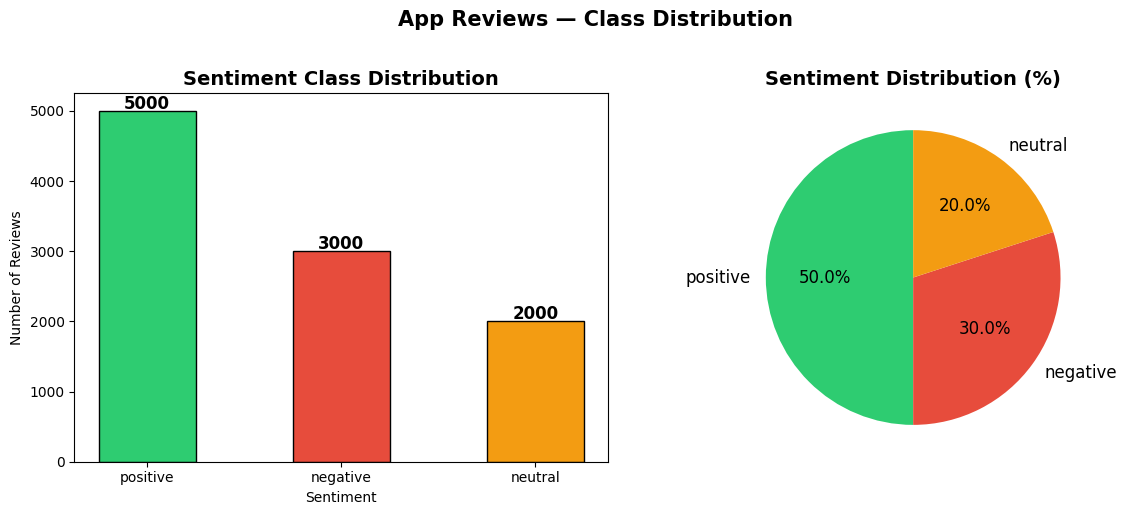

Saved: class_distribution.png


In [10]:
# 2.7 Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c', '#f39c12']
label_counts = df['label'].value_counts()

# Bar chart
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                 str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Sentiment Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('App Reviews — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

In [11]:
# 2.8 Text length statistics
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

print('=== Text Length Statistics (Word Count) ===')
print(df['text_length'].describe().round(2))

print('\n=== Average Text Length by Sentiment ===')
print(df.groupby('label')['text_length'].mean().round(2))

=== Text Length Statistics (Word Count) ===
count    10000.00
mean        17.82
std         16.08
min          1.00
25%          5.00
50%         14.00
75%         26.00
max        186.00
Name: text_length, dtype: float64

=== Average Text Length by Sentiment ===
label
negative    22.19
neutral      8.62
positive    18.88
Name: text_length, dtype: float64


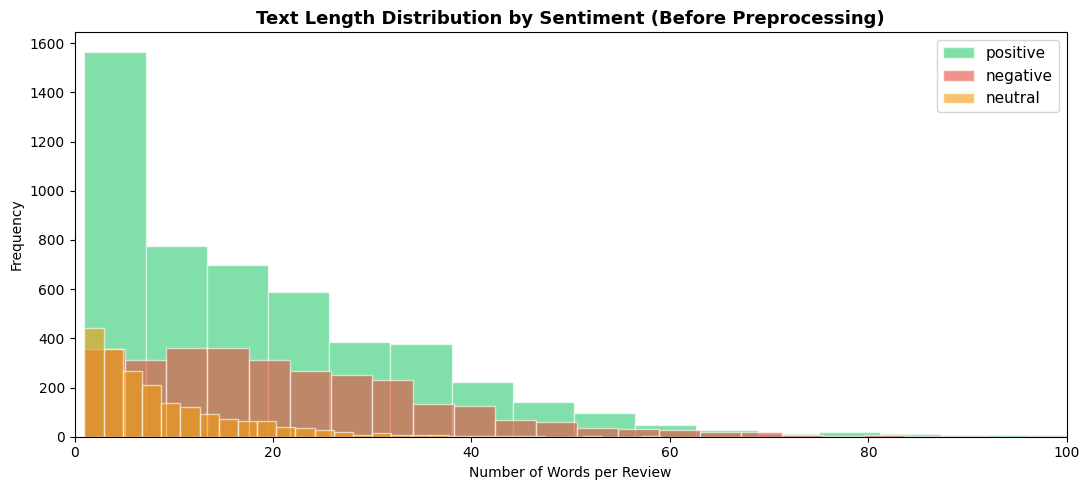

Saved: text_length_distribution.png


In [12]:
# 2.9 Text length distribution visualization
fig, ax = plt.subplots(figsize=(11, 5))

colors_map = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#f39c12'}
for label, color in colors_map.items():
    subset = df[df['label'] == label]['text_length']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

ax.set_title('Text Length Distribution by Sentiment (Before Preprocessing)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Words per Review')
ax.set_ylabel('Frequency')
ax.legend(fontsize=11)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: text_length_distribution.png')

---
## Text Preprocessing Pipeline

Steps applied in order:
1. **Lowercase** — convert all text to lowercase
2. **Remove URLs** — strip http/https/www links
3. **Remove Punctuation** — remove all special characters
4. **Remove Numbers** — remove digits
5. **Tokenization** — split into individual words
6. **Stopword Removal** — remove common words (the, is, and...)
7. **Lemmatization** — reduce words to base form (running → run)

In [13]:
# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print(f'Stopwords loaded: {len(stop_words)} words')
print(f'Sample stopwords: {sorted(list(stop_words))[:15]}')

Stopwords loaded: 198 words
Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [14]:
# Define each preprocessing step as a separate function

def step1_lowercase(text):
    """Step 1: Convert text to lowercase"""
    return str(text).lower()

def step2_remove_urls(text):
    """Step 2: Remove URLs (http, https, www)"""
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE).strip()

def step3_remove_punctuation(text):
    """Step 3: Remove punctuation and special characters"""
    return re.sub(r'[^\w\s]', '', text)

def step4_remove_numbers(text):
    """Step 4: Remove numbers"""
    return re.sub(r'\d+', '', text).strip()

def step5_tokenize(text):
    """Step 5: Tokenize into list of words"""
    return word_tokenize(text)

def step6_remove_stopwords(tokens):
    """Step 6: Remove stopwords, keep words longer than 1 character"""
    return [word for word in tokens if word not in stop_words and len(word) > 1]

def step7_lemmatize(tokens):
    """Step 7: Lemmatize tokens to their base form"""
    return [lemmatizer.lemmatize(word) for word in tokens]

def full_preprocessing_pipeline(text):
    """Apply all 7 steps and return cleaned string"""
    text = step1_lowercase(text)
    text = step2_remove_urls(text)
    text = step3_remove_punctuation(text)
    text = step4_remove_numbers(text)
    tokens = step5_tokenize(text)
    tokens = step6_remove_stopwords(tokens)
    tokens = step7_lemmatize(tokens)
    return ' '.join(tokens)

print('All preprocessing functions defined successfully!')

All preprocessing functions defined successfully!


In [15]:
# Step-by-step demo on a real review
sample = df['text'].iloc[0]
print('=' * 60)
print('PREPROCESSING STEP-BY-STEP DEMO')
print('=' * 60)
print(f'Original text:\n  {sample}')
print()

s1 = step1_lowercase(sample)
print(f'After Step 1 - Lowercase:\n  {s1}')

s2 = step2_remove_urls(s1)
print(f'After Step 2 - Remove URLs:\n  {s2}')

s3 = step3_remove_punctuation(s2)
print(f'After Step 3 - Remove Punctuation:\n  {s3}')

s4 = step4_remove_numbers(s3)
print(f'After Step 4 - Remove Numbers:\n  {s4}')

s5 = step5_tokenize(s4)
print(f'After Step 5 - Tokenization:\n  {s5}')

s6 = step6_remove_stopwords(s5)
print(f'After Step 6 - Stopword Removal:\n  {s6}')

s7 = step7_lemmatize(s6)
print(f'After Step 7 - Lemmatization:\n  {s7}')

print(f'\nFinal cleaned text:\n  {" ".join(s7)}')
print('=' * 60)

PREPROCESSING STEP-BY-STEP DEMO
Original text:
  It never let's schedule appointment. It always HAS comprehensive exam. It gives options, let them, even website. This highly annoying I'm thinking discontinuing services you.

After Step 1 - Lowercase:
  it never let's schedule appointment. it always has comprehensive exam. it gives options, let them, even website. this highly annoying i'm thinking discontinuing services you.
After Step 2 - Remove URLs:
  it never let's schedule appointment. it always has comprehensive exam. it gives options, let them, even website. this highly annoying i'm thinking discontinuing services you.
After Step 3 - Remove Punctuation:
  it never lets schedule appointment it always has comprehensive exam it gives options let them even website this highly annoying im thinking discontinuing services you
After Step 4 - Remove Numbers:
  it never lets schedule appointment it always has comprehensive exam it gives options let them even website this highly annoying im

In [16]:
# Apply full pipeline to all 10,000 reviews
print('Applying preprocessing pipeline to all reviews...')
print('Please wait...')

df['cleaned_text'] = df['text'].apply(full_preprocessing_pipeline)

print(f'Done! Processed {len(df):,} reviews.')

Applying preprocessing pipeline to all reviews...
Please wait...
Done! Processed 10,000 reviews.


In [17]:
# Before vs After comparison table
print('=== Before vs After Preprocessing ===')
comparison = df[['text', 'cleaned_text', 'label']].head(6)
pd.set_option('display.max_colwidth', 70)
comparison

=== Before vs After Preprocessing ===


,text,cleaned_text,label
0,It never let's schedule appointment. It always HAS comprehensive e...,never let schedule appointment always comprehensive exam give opti...,negative
1,Thanks,thanks,positive
2,Good game This really good doesn't make sense 2 options last ditch...,good game really good doesnt make sense option last ditch challeng...,positive
3,Very nice game,nice game,positive
4,"Information easy find, clearly displayed. Screen arrangements effi...",information easy find clearly displayed screen arrangement efficie...,positive
5,I love I super annoyed tweet subsection MLB games stopped working....,love super annoyed tweet subsection mlb game stopped working thoro...,negative


In [18]:
# Remove any empty rows after preprocessing
before = len(df)
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
after = len(df)

print(f'Rows removed (empty after cleaning): {before - after}')
print(f'Final dataset shape: {df.shape}')

Rows removed (empty after cleaning): 20
Final dataset shape: (9980, 5)


In [19]:
# Word count comparison before and after
df['cleaned_length'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

print('=== Word Count: Before vs After Preprocessing ===')
summary = pd.DataFrame({
    'Before Cleaning': df['text_length'].describe().round(2),
    'After Cleaning' : df['cleaned_length'].describe().round(2)
})
print(summary)

reduction = ((df['text_length'].mean() - df['cleaned_length'].mean()) / df['text_length'].mean()) * 100
print(f'\nAverage word count reduction: {reduction:.1f}%')

=== Word Count: Before vs After Preprocessing ===
       Before Cleaning  After Cleaning
count          9980.00         9980.00
mean             17.85           14.53
std              16.08           13.18
min               1.00            1.00
25%               5.00            4.00
50%              14.00           11.00
75%              26.00           21.00
max             186.00          154.00

Average word count reduction: 18.6%


---
##  Post-Preprocessing Visualizations

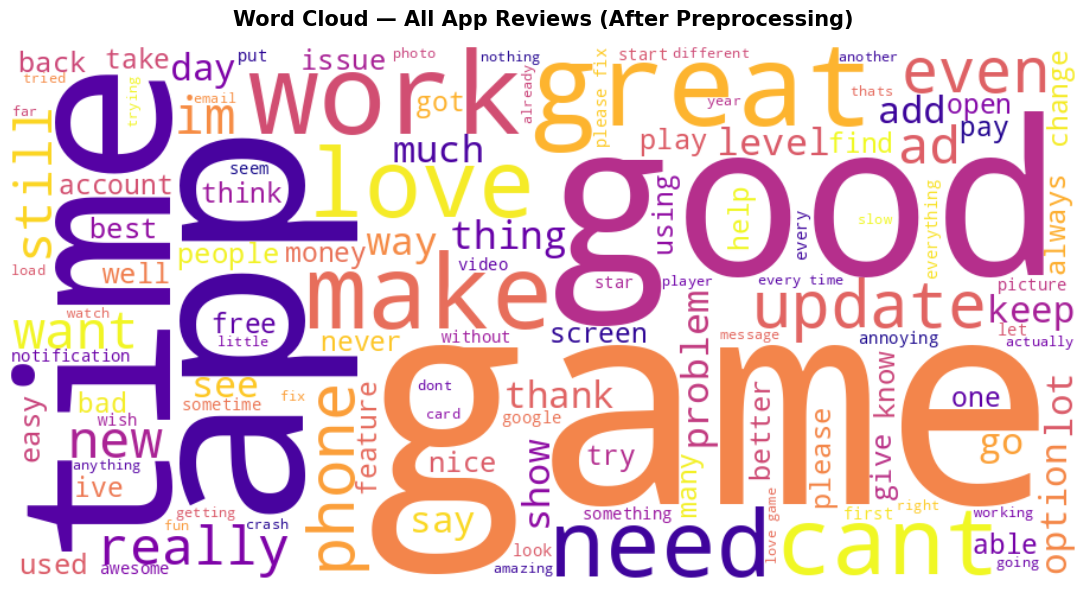

Saved: wordcloud_all.png


In [20]:
# 4.1 Word Cloud — All Reviews Combined
from wordcloud import WordCloud

all_text = ' '.join(df['cleaned_text'].tolist())

wordcloud = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='plasma',
    max_words=120
).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All App Reviews (After Preprocessing)',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: wordcloud_all.png')

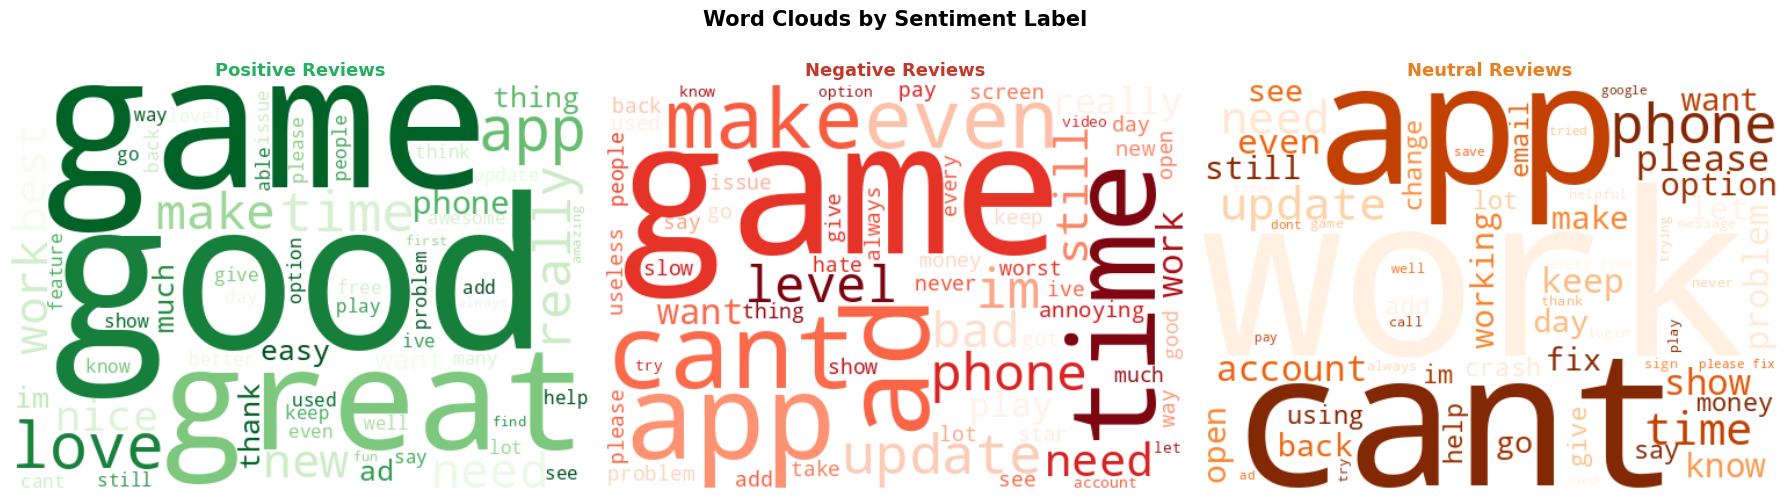

Saved: wordcloud_by_label.png


In [21]:
# 4.2 Word Cloud per Sentiment Label
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('positive', 'Greens',  '#27ae60'),
    ('negative', 'Reds',    '#c0392b'),
    ('neutral',  'Oranges', '#e67e22'),
]

for ax, (label, cmap, tcolor) in zip(axes, configs):
    text = ' '.join(df[df['label'] == label]['cleaned_text'].tolist())
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=cmap, max_words=60).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.capitalize()} Reviews',
                 fontsize=13, fontweight='bold', color=tcolor)

plt.suptitle('Word Clouds by Sentiment Label', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordcloud_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: wordcloud_by_label.png')

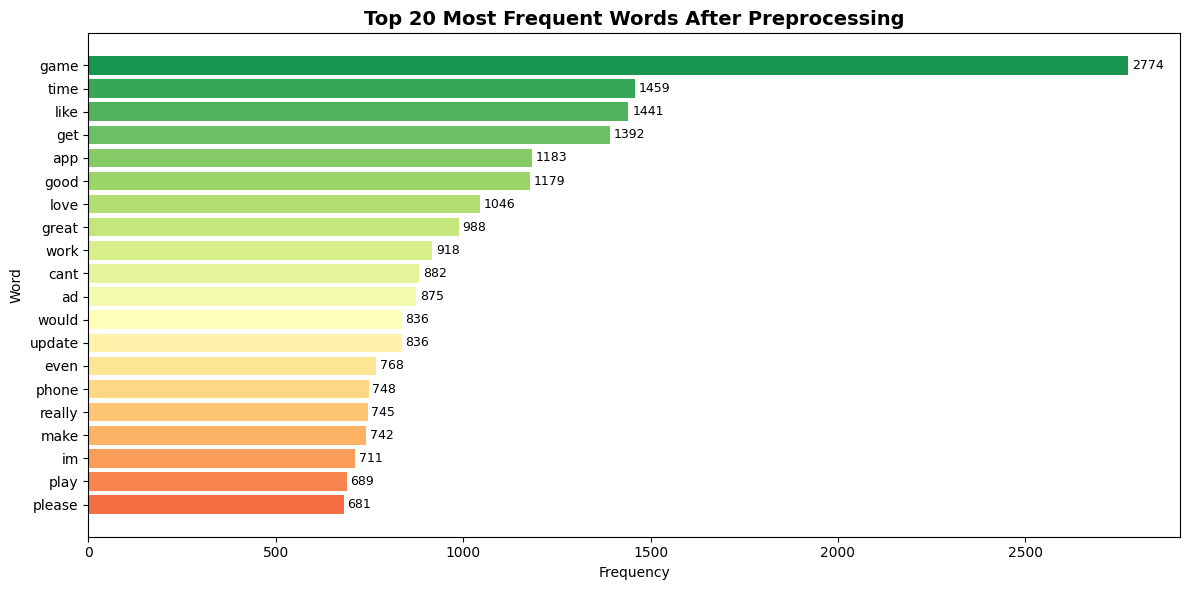

Saved: top20_words.png


In [22]:
# 4.3 Top 20 Most Frequent Words
from collections import Counter

all_words = ' '.join(df['cleaned_text']).split()
word_freq = Counter(all_words)
top20 = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])

plt.figure(figsize=(12, 6))
palette = plt.cm.RdYlGn(np.linspace(0.2, 0.9, 20))
bars = plt.barh(top20['word'][::-1], top20['count'][::-1], color=palette)
plt.title('Top 20 Most Frequent Words After Preprocessing',
          fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word')
for bar, val in zip(bars, top20['count'][::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top20_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top20_words.png')

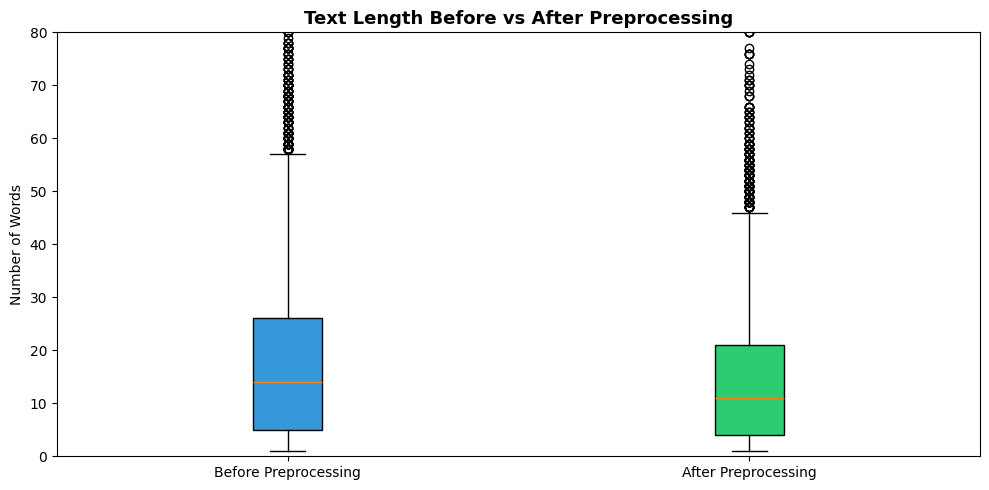

Saved: text_length_boxplot.png


In [27]:
# 4.4 Text length before vs after (side-by-side boxplot)
fig, ax = plt.subplots(figsize=(10, 5))

data_to_plot = [
    df['text_length'].values,
    df['cleaned_length'].values
]
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['Before Preprocessing', 'After Preprocessing'])
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#2ecc71')

ax.set_title('Text Length Before vs After Preprocessing',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Words')
ax.set_ylim(0, 80)
plt.tight_layout()
plt.savefig('text_length_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: text_length_boxplot.png')

---
## Export Cleaned Dataset

In [24]:
# Export cleaned dataset for teammates to use
cleaned_df = df[['text', 'cleaned_text', 'label']].copy()
cleaned_df.to_csv('cleaned_dataset.csv', index=False)

print('=== cleaned_dataset.csv exported successfully! ===')
print(f'Shape             : {cleaned_df.shape}')
print(f'Columns           : {cleaned_df.columns.tolist()}')
print(f'\nLabel distribution:')
print(cleaned_df['label'].value_counts())
print(f'\nPreview:')
cleaned_df.head(3)

=== cleaned_dataset.csv exported successfully! ===
Shape             : (9980, 3)
Columns           : ['text', 'cleaned_text', 'label']

Label distribution:
label
positive    5000
negative    3000
neutral     1980
Name: count, dtype: int64

Preview:


,text,cleaned_text,label
0,It never let's schedule appointment. It always HAS comprehensive e...,never let schedule appointment always comprehensive exam give opti...,negative
1,Thanks,thanks,positive
2,Good game This really good doesn't make sense 2 options last ditch...,good game really good doesnt make sense option last ditch challeng...,positive


In [25]:
# Final pipeline summary
print('=' * 55)
print('   PREPROCESSING PIPELINE — COMPLETE SUMMARY')
print('=' * 55)
print(f'  Total reviews processed  : {len(cleaned_df):,}')
print(f'  Positive reviews         : {sum(cleaned_df["label"]=="positive"):,}')
print(f'  Negative reviews         : {sum(cleaned_df["label"]=="negative"):,}')
print(f'  Neutral reviews          : {sum(cleaned_df["label"]=="neutral"):,}')
print(f'  Avg words before cleaning: {df["text_length"].mean():.1f}')
print(f'  Avg words after cleaning : {df["cleaned_length"].mean():.1f}')
print()
print('  Preprocessing Steps Applied:')
print('    [1] Lowercasing')
print('    [2] URL Removal')
print('    [3] Punctuation Removal')
print('    [4] Number Removal')
print('    [5] Tokenization')
print('    [6] Stopword Removal')
print('    [7] Lemmatization')
print()
print('  Output file: cleaned_dataset.csv')
print('=' * 55)

   PREPROCESSING PIPELINE — COMPLETE SUMMARY
  Total reviews processed  : 9,980
  Positive reviews         : 5,000
  Negative reviews         : 3,000
  Neutral reviews          : 1,980
  Avg words before cleaning: 17.9
  Avg words after cleaning : 14.5

  Preprocessing Steps Applied:
    [1] Lowercasing
    [2] URL Removal
    [3] Punctuation Removal
    [4] Number Removal
    [5] Tokenization
    [6] Stopword Removal
    [7] Lemmatization

  Output file: cleaned_dataset.csv
